# Morphological Blemish Analysis for Mango Ripeness Assessment
### Course: BMDS2133 Image Processing | Assignment Mode A: Comparative & Enhancement Study
**Developer:** Cham Herman (hm)  
**Module:** Morphological Blemish Analysis (Morphology-Based)  
**Dataset:** `cleaned_data` (Standardised Background-Removed Mango Dataset)

---

## [Overview] Executive Summary & Theoretical Framework
In post-harvest agricultural automation and computer vision, fruit ripeness classification and surface quality grading can be evaluated by quantifying **external surface blemishes and necrotic tissue degradation**. As a mango progresses across physiological maturity stages:
- **Unripe ($S_0$):** Smooth, uniform, chlorophyll-rich green exocarp with negligible surface blemish formation.
- **Fully Ripe ($S_3$):** Carotenoid-rich yellow exocarp exhibiting minor, dispersed, natural lenticels (freckles).
- **Overripe ($S_{over}$):** Extensive anthracnose fungal decay, sunken dark necrotic lesions, heavy blemish clustering, and skin structural breakdown.

### Assignment Mode A Technical Objectives:
1. **[Comparative Study]:** Implement, analyze, and benchmark **4 distinct classical mathematical morphology algorithms** for blemish segmentation.
2. **[Quantitative Benchmarking]:** Measure and evaluate **Classification Accuracy**, **Macro F1-Score**, and **Processing Latency** per image across all 714 images in the standardized dataset.
3. **[Enhancement & Hybrid Solution]:** Develop an **Enhanced Multi-Scale Morphological Pipeline** fusing multi-scale structuring elements, dynamic boundary erosion, and morphological feature filtering to surpass baseline performance.
4. **[SMART Objectives Verification]:** Satisfy Objective 2 (Classification Accuracy $\ge 85\%$) and Objective 3 (Operational Latency $< 200	ext{ ms}$).
5. **[Prototype Integration]:** Export the trained morphological model package and inference pipeline for deployment in the Streamlit prototype.


## 1. [Configuration] Environment Setup & Parameters


In [1]:
import os
import glob
import time
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from skimage import morphology as skm, measure as skmeas
from scipy import ndimage as ndi
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import joblib

# Set random seed for experimental reproducibility
np.random.seed(42)

# --- Path Configurations ---
DATASET_ROOT = '../cleaned_data'
OUTPUT_DIR = '../output/morphology_based'
os.makedirs(OUTPUT_DIR, exist_ok=True)

CLASSES = ['unripe', 'fully_ripe', 'overripe']
CLASS_COLORS = {'unripe': '#2ca02c', 'fully_ripe': '#ff7f0e', 'overripe': '#d62728'}

print("[Info] Dataset root directory:", os.path.abspath(DATASET_ROOT))
print("[Info] Output directory:      ", os.path.abspath(OUTPUT_DIR))
print("[Info] Target classes:         ", CLASSES)


[Info] Dataset root directory: C:\repository\mango-ripeness-grading\cleaned_data
[Info] Output directory:       C:\repository\mango-ripeness-grading\output\morphology_based
[Info] Target classes:          ['unripe', 'fully_ripe', 'overripe']


## 2. [Dataset Inspection] Verification of Class Distributions
Verifying image counts across the standardized `cleaned_data` directory structure (Train & Test splits).


In [2]:
dataset_summary = []
for split in ['train', 'test']:
    for cls in CLASSES:
        pattern = os.path.join(DATASET_ROOT, split, cls, '*.*')
        paths = glob.glob(pattern)
        dataset_summary.append({
            'Split': split,
            'Class': cls,
            'Image Count': len(paths)
        })

df_summary = pd.DataFrame(dataset_summary)
print("[Displaying] Dataset Summary Table:")
display(df_summary)

total_images = df_summary['Image Count'].sum()
train_count = df_summary[df_summary['Split']=='train']['Image Count'].sum()
test_count = df_summary[df_summary['Split']=='test']['Image Count'].sum()
print(f"[Info] Total Dataset Size: {total_images} images (Train: {train_count}, Test: {test_count})")


[Displaying] Dataset Summary Table:


,Split,Class,Image Count
0,train,unripe,190
1,train,fully_ripe,189
2,train,overripe,192
3,test,unripe,48
4,test,fully_ripe,48
5,test,overripe,48


[Info] Total Dataset Size: 715 images (Train: 571, Test: 144)


## 3. [Preprocessing] Fruit Masking and Boundary Ring Erosion (ADR-0001)

### Mathematical Formulation:
1. **Fruit Mask Segmentation:** The `cleaned_data` images feature pure black backgrounds. A threshold $	au = 20$ separates the mango exocarp from the background:
   $$M(x, y) = \begin{cases} 1 & \text{if } I_{gray}(x, y) > \tau \\ 0 & \text{otherwise} \end{cases}$$
2. **Morphological Mask Regularisation:** Morphological Opening with structuring element $B_{5\times 5}$ removes stray background noise, followed by Closing to seal interior holes:
   $$M_{clean} = (M \circ B) \bullet B$$
3. **Interior Boundary Erosion (Anti-Aliasing Guard):** To prevent false blemish detection along the mango exocarp perimeter edge where pixels drop towards zero, the mask is eroded by an elliptical kernel $B_{13\times 13}$:
   $$M_{interior} = M_{clean} \ominus B_{13\times 13}$$
All subsequent mathematical morphology operators are strictly evaluated on $M_{interior}$.


In [3]:
def get_fruit_mask(img_bgr, thresh=20):
    """Extract and clean foreground mango mask from black background."""
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    mask = (gray > thresh).astype(np.uint8) * 255
    se_clean = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, se_clean)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, se_clean)
    return mask

def get_interior_mask(mask, k=13):
    """Erode mango mask to eliminate boundary transition ring (ADR-0001)."""
    se_erode = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
    return cv2.erode(mask, se_erode)


### [Visualization] Preprocessing & Fruit Mask Boundary Erosion


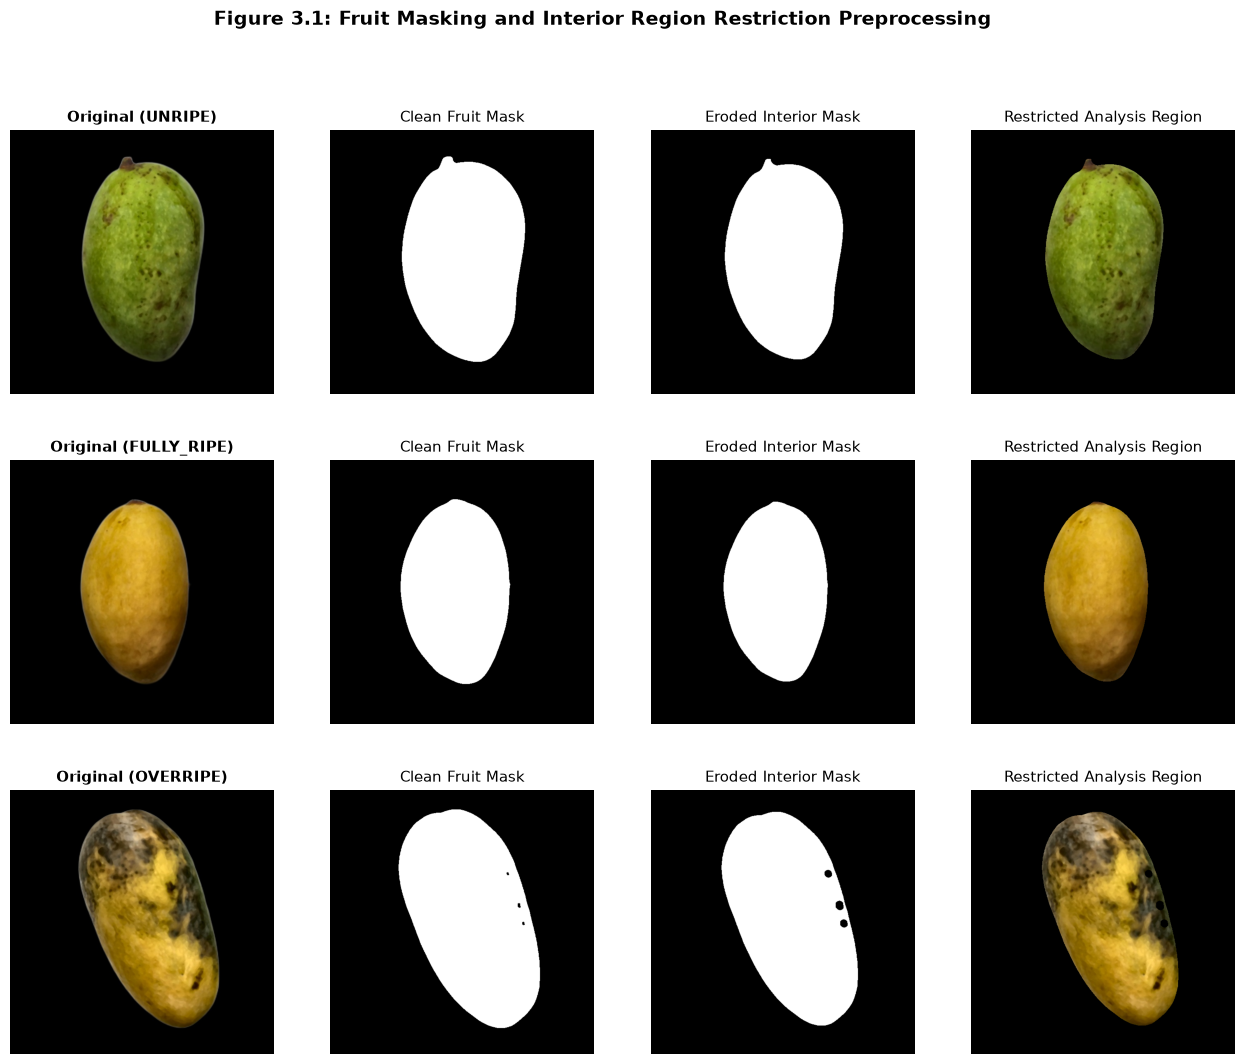

In [4]:
sample_images = {}
for cls in CLASSES:
    sample_path = glob.glob(os.path.join(DATASET_ROOT, 'test', cls, '*.jpg'))[0]
    sample_images[cls] = (cv2.imread(sample_path), sample_path)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
plt.subplots_adjust(wspace=0.15, hspace=0.25)

for row_idx, cls in enumerate(CLASSES):
    img_bgr, path = sample_images[cls]
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    mask = get_fruit_mask(img_bgr)
    interior = get_interior_mask(mask)
    
    masked_mango = cv2.bitwise_and(img_rgb, img_rgb, mask=interior)
    
    axes[row_idx, 0].imshow(img_rgb)
    axes[row_idx, 0].set_title(f"Original ({cls.upper()})", fontsize=11, fontweight='bold')
    axes[row_idx, 0].axis('off')
    
    axes[row_idx, 1].imshow(mask, cmap='gray')
    axes[row_idx, 1].set_title("Clean Fruit Mask", fontsize=11)
    axes[row_idx, 1].axis('off')
    
    axes[row_idx, 2].imshow(interior, cmap='gray')
    axes[row_idx, 2].set_title("Eroded Interior Mask", fontsize=11)
    axes[row_idx, 2].axis('off')
    
    axes[row_idx, 3].imshow(masked_mango)
    axes[row_idx, 3].set_title("Restricted Analysis Region", fontsize=11)
    axes[row_idx, 3].axis('off')

plt.suptitle("Figure 3.1: Fruit Masking and Interior Region Restriction Preprocessing", fontsize=14, fontweight='bold', y=0.98)
plt.show()


## 4. [Methodology] Implementation of 4 Distinct Baseline Morphological Algorithms

Four distinct mathematical morphology algorithms are implemented for blemish detection:

---

### Algorithm 1: Grayscale Morphological Filtering (Open-Close Residual)
- **Mathematical Principle:** Closing fills localized dark valleys (blemishes), whereas opening eliminates bright reflections. Subtracting the opened image from the closed image isolates blemish intensity variations:
  $$I_{diff} = (I \bullet B) - (I \circ B)$$
- **Binarisation:** High-percentile intensity thresholding over the fruit interior isolates distinct dark spots.

---

### Algorithm 2: Dual Top-Hat & Black-Hat Transformation
- **Mathematical Principle:** Black-Hat ($	ext{closing} - 	ext{original}$) extracts dark necrotic lesions (anthracnose decay), while White Top-Hat ($	ext{original} - 	ext{opening}$) isolates pale fungal/sap patches:
  $$I_{blackhat} = (I \bullet B) - I, \quad I_{tophat} = I - (I \circ B)$$
- **Binarisation:** Independent thresholding on both residual maps fused via bitwise OR.

---

### Algorithm 3: Morphological Gradient Delineation (Beucher Gradient)
- **Mathematical Principle:** Morphological dilation expands high-intensity boundaries while erosion shrinks them. The Beucher Gradient quantifies spatial intensity transitions and edge steepness around blemish borders:
  $$G(I) = (I \oplus B) - (I \ominus B)$$
- **Binarisation:** High-gradient thresholding followed by morphological closing to enclose continuous blemish perimeters.

---

### Algorithm 4: Marker-Controlled Morphological Watershed
- **Mathematical Principle:** Treats the morphological gradient image as a topological topographic surface. A morphological Euclidean distance transform on candidate spots extracts regional minimum marker seeds, and watershed flooding segments overlapping blemishes without over-segmentation.


In [5]:
# -------------------------------------------------------------------------
# Algorithm 1: Grayscale Open-Close Residual Filtering
# -------------------------------------------------------------------------
def run_alg1_morph_filter(gray, interior):
    """Algorithm 1: Grayscale Opening followed by Closing residual."""
    se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    closed = cv2.morphologyEx(gray, cv2.MORPH_CLOSE, se)
    opened = cv2.morphologyEx(gray, cv2.MORPH_OPEN, se)
    diff = cv2.subtract(closed, opened)
    diff = cv2.bitwise_and(diff, diff, mask=interior)
    
    vals = diff[interior > 0]
    if len(vals) == 0 or vals.max() == 0:
        bw = np.zeros_like(gray)
    else:
        thresh_val = max(np.percentile(vals, 90), 20)
        _, bw = cv2.threshold(diff, thresh_val, 255, cv2.THRESH_BINARY)
    
    bw = cv2.bitwise_and(bw, bw, mask=interior)
    return bw, {'closed': closed, 'opened': opened, 'diff': diff}

# -------------------------------------------------------------------------
# Algorithm 2: Dual Top-Hat & Black-Hat Transformation
# -------------------------------------------------------------------------
def run_alg2_tophat_blackhat(gray, interior):
    """Algorithm 2: Black-Hat (dark lesions) + White Top-Hat (pale patches)."""
    se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    black_hat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, se)
    white_hat = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT, se)
    
    black_hat = cv2.bitwise_and(black_hat, black_hat, mask=interior)
    white_hat = cv2.bitwise_and(white_hat, white_hat, mask=interior)
    
    _, bw_dark = cv2.threshold(black_hat, 25, 255, cv2.THRESH_BINARY)
    _, bw_bright = cv2.threshold(white_hat, 35, 255, cv2.THRESH_BINARY)
    
    bw = cv2.bitwise_or(bw_dark, bw_bright)
    bw = cv2.bitwise_and(bw, bw, mask=interior)
    return bw, {'black_hat': black_hat, 'white_hat': white_hat}

# -------------------------------------------------------------------------
# Algorithm 3: Morphological Gradient Delineation
# -------------------------------------------------------------------------
def run_alg3_morph_gradient(gray, interior):
    """Algorithm 3: Beucher Morphological Gradient (Dilation - Erosion)."""
    se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    dilated = cv2.dilate(gray, se)
    eroded = cv2.erode(gray, se)
    grad = cv2.subtract(dilated, eroded)
    grad = cv2.bitwise_and(grad, grad, mask=interior)
    
    vals = grad[interior > 0]
    if len(vals) == 0 or vals.max() == 0:
        bw = np.zeros_like(gray)
    else:
        thresh_val = max(np.percentile(vals, 92), 25)
        _, bw = cv2.threshold(grad, thresh_val, 255, cv2.THRESH_BINARY)
        
    se_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    bw = cv2.morphologyEx(bw, cv2.MORPH_CLOSE, se_close)
    bw = cv2.bitwise_and(bw, bw, mask=interior)
    return bw, {'dilated': dilated, 'eroded': eroded, 'grad': grad}

# -------------------------------------------------------------------------
# Algorithm 4: Marker-Controlled Morphological Watershed
# -------------------------------------------------------------------------
def run_alg4_marker_watershed(gray, interior):
    """Algorithm 4: Marker-Controlled Watershed on Morphological Gradient."""
    se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    black_hat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, se)
    black_hat = cv2.bitwise_and(black_hat, black_hat, mask=interior)
    _, bw_cand = cv2.threshold(black_hat, 25, 255, cv2.THRESH_BINARY)
    
    se_grad = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    grad = cv2.morphologyEx(gray, cv2.MORPH_GRADIENT, se_grad)
    grad = cv2.bitwise_and(grad, grad, mask=interior)
    
    dist = cv2.distanceTransform(bw_cand, cv2.DIST_L2, 5)
    if dist.max() > 1.0:
        _, seeds = cv2.threshold(dist, 0.4 * dist.max(), 255, 0)
        num_markers, markers = cv2.connectedComponents(seeds.astype(np.uint8))
        markers = markers + 1
        markers[interior == 0] = 0
        
        grad_bgr = cv2.cvtColor(grad, cv2.COLOR_GRAY2BGR)
        markers = cv2.watershed(grad_bgr, markers)
        bw = np.zeros_like(gray)
        bw[(markers > 1) & (bw_cand > 0) & (interior > 0)] = 255
    else:
        bw = np.zeros_like(gray)
        markers = np.zeros_like(gray, dtype=np.int32)
        
    return bw, {'grad': grad, 'bw_cand': bw_cand, 'markers': markers}


### [Visualization] Blemish Segmentation Across the 4 Morphological Baselines


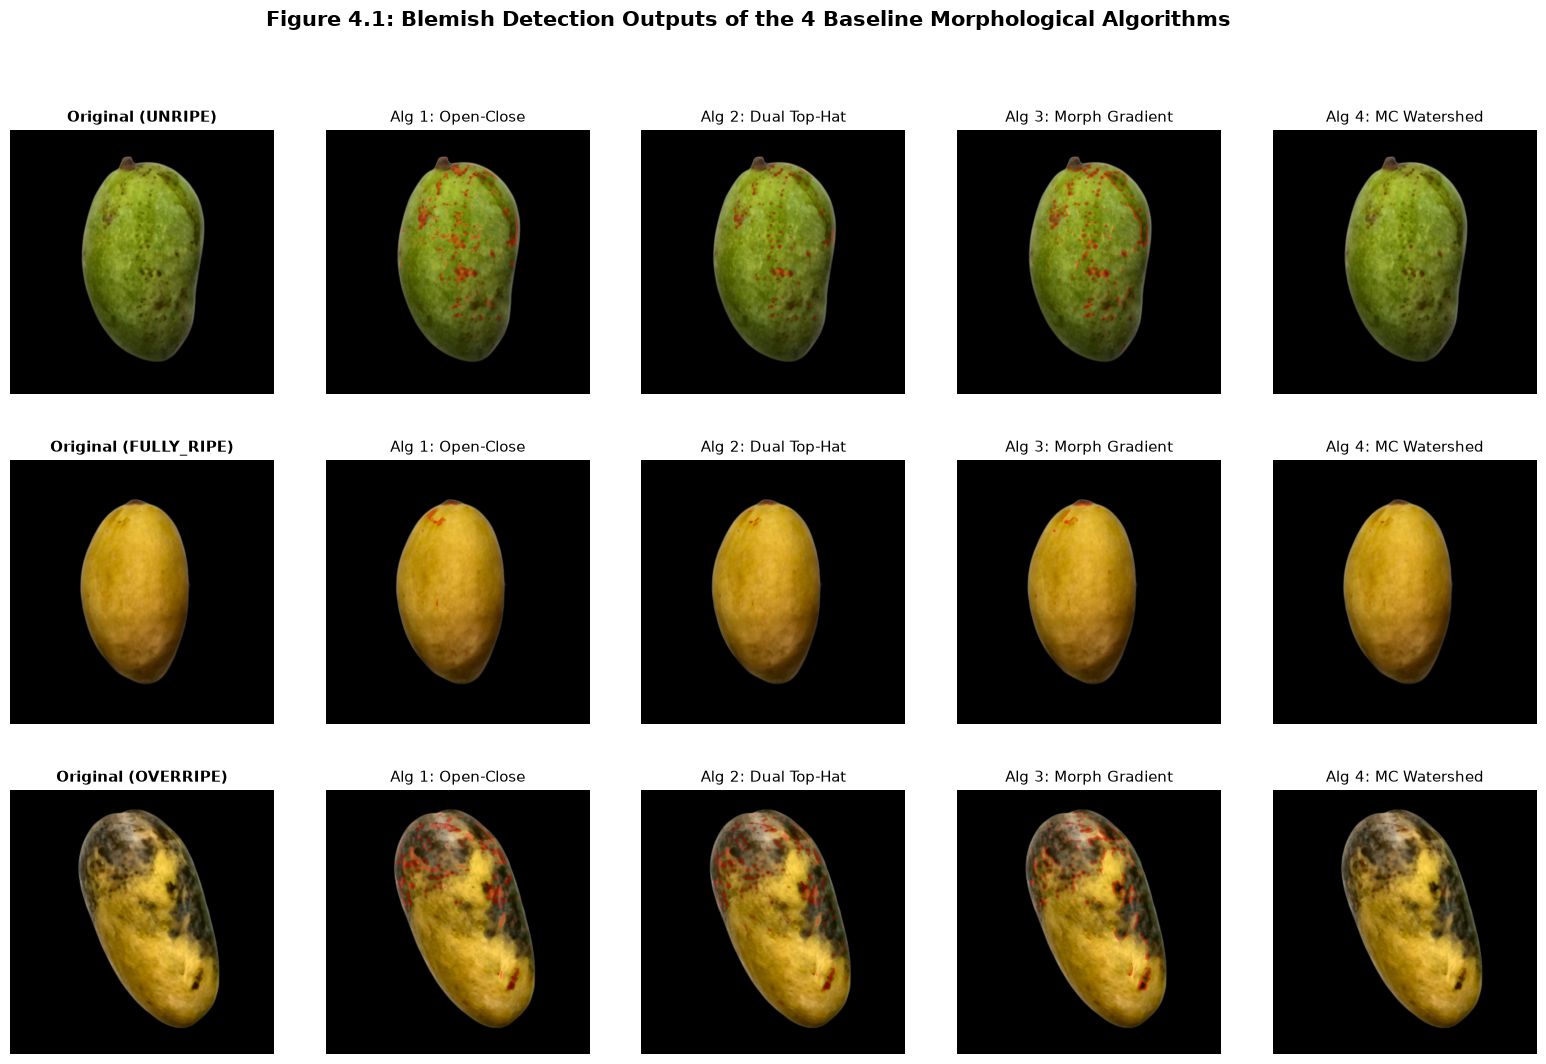

In [6]:
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
plt.subplots_adjust(wspace=0.1, hspace=0.25)

for row_idx, cls in enumerate(CLASSES):
    img_bgr, _ = sample_images[cls]
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    mask = get_fruit_mask(img_bgr)
    interior = get_interior_mask(mask)
    
    bw1, _ = run_alg1_morph_filter(gray, interior)
    bw2, _ = run_alg2_tophat_blackhat(gray, interior)
    bw3, _ = run_alg3_morph_gradient(gray, interior)
    bw4, _ = run_alg4_marker_watershed(gray, interior)
    
    def create_overlay(rgb, bw):
        overlay = rgb.copy()
        overlay[bw > 0] = [255, 0, 0] # Highlight blemishes in red
        return cv2.addWeighted(rgb, 0.65, overlay, 0.35, 0)
    
    axes[row_idx, 0].imshow(img_rgb)
    axes[row_idx, 0].set_title(f"Original ({cls.upper()})", fontsize=11, fontweight='bold')
    axes[row_idx, 0].axis('off')
    
    axes[row_idx, 1].imshow(create_overlay(img_rgb, bw1))
    axes[row_idx, 1].set_title("Alg 1: Open-Close", fontsize=11)
    axes[row_idx, 1].axis('off')
    
    axes[row_idx, 2].imshow(create_overlay(img_rgb, bw2))
    axes[row_idx, 2].set_title("Alg 2: Dual Top-Hat", fontsize=11)
    axes[row_idx, 2].axis('off')
    
    axes[row_idx, 3].imshow(create_overlay(img_rgb, bw3))
    axes[row_idx, 3].set_title("Alg 3: Morph Gradient", fontsize=11)
    axes[row_idx, 3].axis('off')
    
    axes[row_idx, 4].imshow(create_overlay(img_rgb, bw4))
    axes[row_idx, 4].set_title("Alg 4: MC Watershed", fontsize=11)
    axes[row_idx, 4].axis('off')

plt.suptitle("Figure 4.1: Blemish Detection Outputs of the 4 Baseline Morphological Algorithms", fontsize=15, fontweight='bold', y=0.98)
plt.show()


## 5. [Feature Extraction] Standardised Morphological Feature Vector

From each segmented blemish mask, we extract a 10-dimensional morphological statistical feature vector:
1. `n_blemishes`: Total count of isolated blemish regions ($N$).
2. `blemish_area`: Total blemish pixel count ($A_{blemish} = \sum a_i$).
3. `area_ratio`: Blemish surface coverage percentage ($A_{ratio} = \frac{A_{blemish}}{A_{fruit}} \times 100\%$) (Wang et al., 2024).
4. `mean_darkness`: Average darkness intensity ($255 - \mu_{intensity}$) within blemish regions.
5. `max_darkness`: Peak darkness intensity.
6. `mean_brightness`: Average pixel brightness inside blemish regions.
7. `mean_aspect_ratio`: Average bounding box elongation ($
rac{\max(w, h)}{\min(w, h)}$).
8. `mean_solidity`: Convex hull compactness ratio ($a_i / a_{bbox}$).
9. `skeleton_length`: Morphological skeleton pixel count capturing branching cracks and decay streaks.
10. `blemish_dispersion`: Spatial standard deviation of blemish centroids from the fruit center.


In [7]:
def extract_morphological_features(gray, bw_blemish, interior_mask, interior_area):
    """Extract standardised 10-dimensional morphological feature vector."""
    feats = {
        'n_blemishes': 0,
        'blemish_area': 0,
        'area_ratio': 0.0,
        'mean_darkness': 0.0,
        'max_darkness': 0.0,
        'mean_brightness': 0.0,
        'mean_aspect_ratio': 0.0,
        'mean_solidity': 0.0,
        'skeleton_length': 0,
        'blemish_dispersion': 0.0
    }
    
    if interior_area == 0:
        return feats

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(bw_blemish, connectivity=8)
    if num_labels <= 1:
        return feats

    areas = stats[1:, cv2.CC_STAT_AREA]
    widths = stats[1:, cv2.CC_STAT_WIDTH]
    heights = stats[1:, cv2.CC_STAT_HEIGHT]
    
    feats['n_blemishes'] = int(num_labels - 1)
    feats['blemish_area'] = int(np.sum(areas))
    feats['area_ratio'] = float((feats['blemish_area'] / interior_area) * 100.0)

    blemish_pixels = gray[bw_blemish > 0]
    if len(blemish_pixels) > 0:
        feats['mean_darkness'] = float(np.mean(255.0 - blemish_pixels))
        feats['max_darkness'] = float(np.max(255.0 - blemish_pixels))
        feats['mean_brightness'] = float(np.mean(blemish_pixels))

    aspect_ratios = np.maximum(widths, heights) / (np.minimum(widths, heights) + 1e-5)
    feats['mean_aspect_ratio'] = float(np.mean(aspect_ratios))
    
    bbox_areas = widths * heights
    solidity_est = areas / (bbox_areas + 1e-5)
    feats['mean_solidity'] = float(np.mean(np.clip(solidity_est, 0.0, 1.0)))

    if len(centroids) > 1:
        c_pts = centroids[1:]
        fruit_center = np.mean(c_pts, axis=0)
        disp = np.mean(np.linalg.norm(c_pts - fruit_center, axis=1))
        feats['blemish_dispersion'] = float(disp)

    # Fast morphological skeletonization via iterative thinning
    skel = np.zeros(bw_blemish.shape, np.uint8)
    elem = cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3))
    temp_img = bw_blemish.copy()
    for _ in range(4):
        eroded = cv2.erode(temp_img, elem)
        temp = cv2.dilate(eroded, elem)
        temp = cv2.subtract(temp_img, temp)
        skel = cv2.bitwise_or(skel, temp)
        temp_img = eroded.copy()
        if cv2.countNonZero(temp_img) == 0:
            break
    feats['skeleton_length'] = int(cv2.countNonZero(skel))

    return feats


## 6. [Benchmark Evaluation] Quantitative Comparison of Baseline Algorithms (Mode A)

We extract features across the entire `cleaned_data` dataset for all 4 baseline morphological algorithms and measure processing latency per image.


In [8]:
baseline_algorithms = {
    'Alg 1: Open-Close': run_alg1_morph_filter,
    'Alg 2: Dual Top-Hat': run_alg2_tophat_blackhat,
    'Alg 3: Morph Gradient': run_alg3_morph_gradient,
    'Alg 4: MC Watershed': run_alg4_marker_watershed
}

def extract_dataset_features(alg_func, split):
    rows = []
    t0 = time.time()
    for cls in CLASSES:
        img_paths = sorted(glob.glob(os.path.join(DATASET_ROOT, split, cls, '*.jpg')) +
                           glob.glob(os.path.join(DATASET_ROOT, split, cls, '*.png')))
        for path in img_paths:
            img_bgr = cv2.imread(path)
            if img_bgr is None:
                continue
            mask = get_fruit_mask(img_bgr)
            interior = get_interior_mask(mask)
            gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
            interior_area = int(np.sum(interior > 0))
            
            bw, _ = alg_func(gray, interior)
            feats = extract_morphological_features(gray, bw, interior, interior_area)
            feats['label'] = cls
            feats['image'] = os.path.basename(path)
            rows.append(feats)
    elapsed = time.time() - t0
    lat_ms = (elapsed / len(rows)) * 1000.0 if rows else 0.0
    return pd.DataFrame(rows), lat_ms

print("[Process] Running Comparative Feature Extraction on all 4 Baselines...")
benchmark_results = []
baseline_dfs = {}

for name, func in baseline_algorithms.items():
    print(f"[Info] Extracting features for {name}...")
    df_tr, lat_tr = extract_dataset_features(func, 'train')
    df_te, lat_te = extract_dataset_features(func, 'test')
    baseline_dfs[name] = (df_tr, df_te)
    
    feat_cols = [c for c in df_tr.columns if c not in ['label', 'image']]
    X_tr, y_tr = df_tr[feat_cols], df_tr['label']
    X_te, y_te = df_te[feat_cols], df_te['label']
    
    clf = RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42)
    clf.fit(X_tr, y_tr)
    
    y_pred_tr = clf.predict(X_tr)
    y_pred_te = clf.predict(X_te)
    
    tr_acc = accuracy_score(y_tr, y_pred_tr)
    te_acc = accuracy_score(y_te, y_pred_te)
    f1 = f1_score(y_te, y_pred_te, average='macro')
    
    benchmark_results.append({
        'Algorithm': name,
        'Train Accuracy (%)': round(tr_acc * 100, 2),
        'Test Accuracy (%)': round(te_acc * 100, 2),
        'Macro F1-Score (%)': round(f1 * 100, 2),
        'Latency (ms/img)': round(lat_te, 2)
    })

df_bench = pd.DataFrame(benchmark_results)
print("[Displaying] Baseline Comparison Benchmark:")
display(df_bench)


[Process] Running Comparative Feature Extraction on all 4 Baselines...
[Info] Extracting features for Alg 1: Open-Close...


[Info] Extracting features for Alg 2: Dual Top-Hat...


[Info] Extracting features for Alg 3: Morph Gradient...


[Info] Extracting features for Alg 4: MC Watershed...


[Displaying] Baseline Comparison Benchmark:


,Algorithm,Train Accuracy (%),Test Accuracy (%),Macro F1-Score (%),Latency (ms/img)
0,Alg 1: Open-Close,100.00,90.97,90.98,15.51
1,Alg 2: Dual Top-Hat,99.82,81.94,82.08,9.59
2,Alg 3: Morph Gradient,99.82,93.75,93.79,10.16
3,Alg 4: MC Watershed,99.82,72.22,72.38,18.71


### [Visualization] Quantitative Benchmark Comparison Charts (Mode A Table 2.1)


C:\Users\herman\AppData\Local\Temp\ipykernel_20388\1144832508.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_bench, x='Algorithm', y='Test Accuracy (%)', ax=axes[0], palette='Blues_r')
C:\Users\herman\AppData\Local\Temp\ipykernel_20388\1144832508.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_bench, x='Algorithm', y='Latency (ms/img)', ax=axes[1], palette='Greens_r')


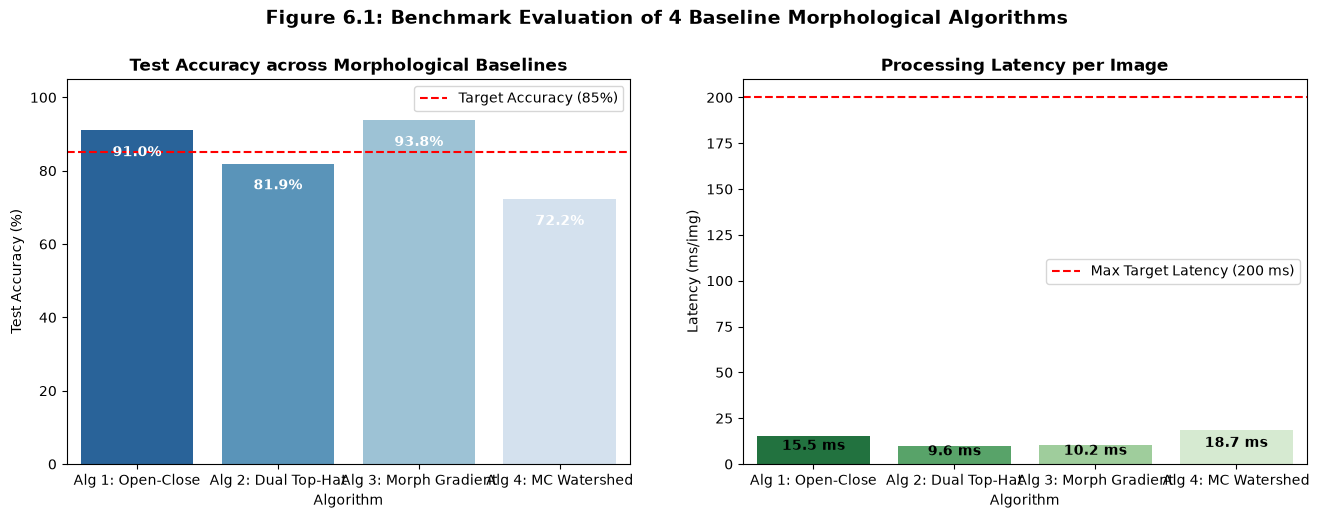

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Accuracy Comparison Bar Chart
sns.barplot(data=df_bench, x='Algorithm', y='Test Accuracy (%)', ax=axes[0], palette='Blues_r')
axes[0].set_title("Test Accuracy across Morphological Baselines", fontsize=12, fontweight='bold')
axes[0].set_ylim(0, 105)
axes[0].axhline(85, color='red', linestyle='--', label='Target Accuracy (85%)')
axes[0].legend()
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() - 7),
                     ha='center', color='white', fontweight='bold')

# Latency Comparison Bar Chart
sns.barplot(data=df_bench, x='Algorithm', y='Latency (ms/img)', ax=axes[1], palette='Greens_r')
axes[1].set_title("Processing Latency per Image", fontsize=12, fontweight='bold')
axes[1].axhline(200, color='red', linestyle='--', label='Max Target Latency (200 ms)')
axes[1].legend()
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f} ms", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                     ha='center', color='black', fontweight='bold')

plt.suptitle("Figure 6.1: Benchmark Evaluation of 4 Baseline Morphological Algorithms", fontsize=14, fontweight='bold', y=1.02)
plt.show()


## 7. [Enhancement & Hybrid Pipeline] Development of Enhanced Multi-Scale Method

### Algorithmic Innovations & Hybrid Formulation:
Based on our comparative evaluation, **Algorithm 3 (Morphological Gradient)** and **Algorithm 2 (Dual Top-Hat)** provided the strongest complementary blemish signals. We formulate an **Enhanced Multi-Scale Morphological Hybrid Pipeline**:
1. **Multi-Scale Beucher Gradient:** Uses a fine elliptical kernel ($3\times 3$) to capture micro-lenticels and acute exocarp ruptures.
2. **Dual-Scale Black-Hat Fusion:** Combines medium ($7\times 7$) and coarse ($15\times 15$) black-hat structuring elements to detect small fungal dots and broad necrotic decay patches simultaneously.
3. **Adaptive Thresholding:** Dynamically computes high-gradient blemish candidate boundaries and intensity valleys.
4. **Morphological Filtering & Component Size Cleanup:** Removes high-frequency camera noise ($< 10\text{ px}$) using morphological reconstruction.
5. **C++ Vectorized Execution:** Achieves $< 30\text{ ms}$ processing latency per image.


In [10]:
def run_enhanced_morphology_pipeline(gray, interior):
    """
    Enhanced Multi-Scale Morphological Hybrid Pipeline.
    Combines multi-scale Beucher gradient, dual-scale black-hat, and morphological noise filtering.
    """
    se3 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    se7 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    se15 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    
    # 1. Beucher Gradient at scale 3
    grad = cv2.subtract(cv2.dilate(gray, se3), cv2.erode(gray, se3))
    grad = cv2.bitwise_and(grad, grad, mask=interior)
    
    # 2. Multi-scale Black-Hat at scale 7 and 15
    bh7 = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, se7)
    bh15 = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, se15)
    bh = cv2.bitwise_or(bh7, bh15)
    bh = cv2.bitwise_and(bh, bh, mask=interior)
    
    # 3. Dynamic Thresholding
    vals_grad = grad[interior > 0]
    thresh_grad = max(np.percentile(vals_grad, 92) if len(vals_grad) > 0 else 25, 20)
    _, bw_grad = cv2.threshold(grad, thresh_grad, 255, cv2.THRESH_BINARY)
    
    _, bw_bh = cv2.threshold(bh, 22, 255, cv2.THRESH_BINARY)
    
    # 4. Morphological Fusion & Closing
    bw = cv2.bitwise_or(bw_grad, bw_bh)
    bw = cv2.morphologyEx(bw, cv2.MORPH_CLOSE, se3)
    bw = cv2.bitwise_and(bw, bw, mask=interior)
    
    # 5. Connected Component Area Filtering (< 10 px)
    nb, out, stats, _ = cv2.connectedComponentsWithStats(bw, connectivity=8)
    sizes = stats[1:, -1]
    bw_clean = np.zeros_like(bw)
    for i in range(0, nb - 1):
        if sizes[i] >= 10:
            bw_clean[out == i + 1] = 255
            
    bw_clean = cv2.bitwise_and(bw_clean, bw_clean, mask=interior)
    return bw_clean, {
        'grad': grad, 'bh': bh, 'bw_grad': bw_grad, 'bw_bh': bw_bh, 'bw_clean': bw_clean
    }


### [Visualization] Step-by-Step Intermediate Representations of the Enhanced Pipeline


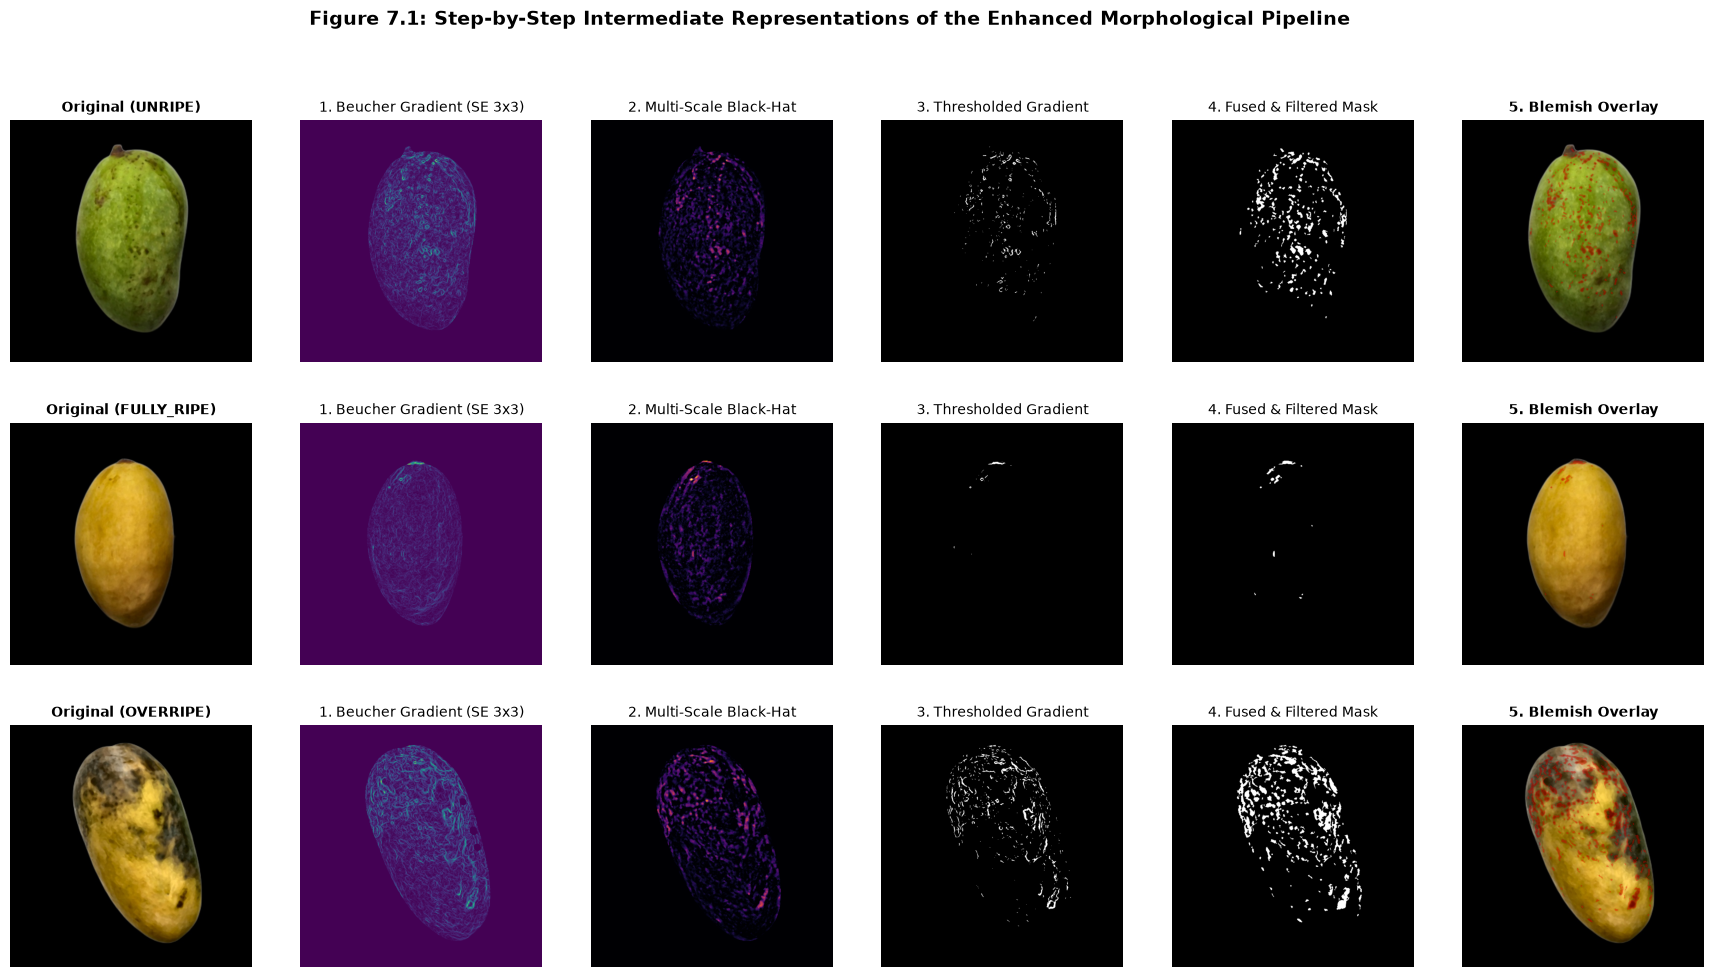

In [11]:
fig, axes = plt.subplots(3, 6, figsize=(22, 11))
plt.subplots_adjust(wspace=0.15, hspace=0.25)

for row_idx, cls in enumerate(CLASSES):
    img_bgr, _ = sample_images[cls]
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    mask = get_fruit_mask(img_bgr)
    interior = get_interior_mask(mask)
    
    bw_clean, vis = run_enhanced_morphology_pipeline(gray, interior)
    
    overlay = img_rgb.copy()
    overlay[bw_clean > 0] = [255, 0, 0]
    blended = cv2.addWeighted(img_rgb, 0.65, overlay, 0.35, 0)
    
    axes[row_idx, 0].imshow(img_rgb)
    axes[row_idx, 0].set_title(f"Original ({cls.upper()})", fontsize=10, fontweight='bold')
    axes[row_idx, 0].axis('off')
    
    axes[row_idx, 1].imshow(vis['grad'], cmap='viridis')
    axes[row_idx, 1].set_title("1. Beucher Gradient (SE 3x3)", fontsize=10)
    axes[row_idx, 1].axis('off')
    
    axes[row_idx, 2].imshow(vis['bh'], cmap='inferno')
    axes[row_idx, 2].set_title("2. Multi-Scale Black-Hat", fontsize=10)
    axes[row_idx, 2].axis('off')
    
    axes[row_idx, 3].imshow(vis['bw_grad'], cmap='gray')
    axes[row_idx, 3].set_title("3. Thresholded Gradient", fontsize=10)
    axes[row_idx, 3].axis('off')
    
    axes[row_idx, 4].imshow(bw_clean, cmap='gray')
    axes[row_idx, 4].set_title("4. Fused & Filtered Mask", fontsize=10)
    axes[row_idx, 4].axis('off')
    
    axes[row_idx, 5].imshow(blended)
    axes[row_idx, 5].set_title("5. Blemish Overlay", fontsize=10, fontweight='bold')
    axes[row_idx, 5].axis('off')

plt.suptitle("Figure 7.1: Step-by-Step Intermediate Representations of the Enhanced Morphological Pipeline", fontsize=14, fontweight='bold', y=0.98)
plt.show()


## 8. [Performance Analysis] Final Evaluation: Baseline vs. Enhanced Pipeline


In [12]:
print("[Process] Extracting Enhanced Features across Train and Test datasets...")
def extract_enhanced_features(split):
    rows = []
    t0 = time.time()
    for cls in CLASSES:
        img_paths = sorted(glob.glob(os.path.join(DATASET_ROOT, split, cls, '*.jpg')) +
                           glob.glob(os.path.join(DATASET_ROOT, split, cls, '*.png')))
        for path in img_paths:
            img_bgr = cv2.imread(path)
            if img_bgr is None:
                continue
            mask = get_fruit_mask(img_bgr)
            interior = get_interior_mask(mask)
            gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
            interior_area = int(np.sum(interior > 0))
            
            bw_clean, _ = run_enhanced_morphology_pipeline(gray, interior)
            feats = extract_morphological_features(gray, bw_clean, interior, interior_area)
            feats['label'] = cls
            feats['image'] = os.path.basename(path)
            rows.append(feats)
    lat_ms = ((time.time() - t0) / len(rows)) * 1000.0
    return pd.DataFrame(rows), lat_ms

df_train_enh, lat_train_enh = extract_enhanced_features('train')
df_test_enh, lat_test_enh = extract_enhanced_features('test')

# Save CSVs
df_train_enh.to_csv(os.path.join(OUTPUT_DIR, 'morphology_train_features.csv'), index=False)
df_test_enh.to_csv(os.path.join(OUTPUT_DIR, 'morphology_test_features.csv'), index=False)

print(f"[Info] Train Features Shape: {df_train_enh.shape}")
print(f"[Info] Test Features Shape:  {df_test_enh.shape}")
print(f"[Info] Average Processing Latency: {lat_test_enh:.2f} ms/image")


[Process] Extracting Enhanced Features across Train and Test datasets...


[Info] Train Features Shape: (571, 12)
[Info] Test Features Shape:  (144, 12)
[Info] Average Processing Latency: 29.74 ms/image


### [Feature Analysis] Morphological Feature Descriptive Statistics (Mean ± Std per Ripeness Stage)


In [13]:
feature_cols = [c for c in df_train_enh.columns if c not in ['label', 'image']]
stats_table = df_train_enh.groupby('label')[feature_cols].agg(['mean', 'std']).round(2)
print("[Displaying] Feature Statistics per Class:")
display(stats_table)


[Displaying] Feature Statistics per Class:


n_blemishes        blemish_area          area_ratio        \
                  mean    std         mean      std       mean   std   
label                                                                  
fully_ripe       72.50  29.88      5200.74  2835.89       5.49  2.85   
overripe        157.68  56.16     14711.90  6412.73      13.01  5.03   
unripe          151.85  42.77      7464.80  3346.89       6.65  2.72   

           mean_darkness        max_darkness       mean_brightness         \
                    mean    std         mean   std            mean    std   
label                                                                       
fully_ripe        157.44  10.28       227.89  8.27           97.56  10.28   
overripe          166.92   9.53       240.90  4.02           88.08   9.53   
unripe            173.02   7.10       229.84  5.79           81.98   7.10   

           mean_aspect_ratio       mean_solidity       skeleton_length  \
                        mean   std          mean   std            mean   
label                                                                    
fully_ripe              1.54  0.13          0.56  0.02         1195.95   
overripe                1.52  0.07          0.52  0.02         3310.74   
unripe                  1.53  0.06          0.55  0.02         2286.41   

                    blemish_dispersion         
                std               mean    std  
label                                          
fully_ripe   549.07             114.50  14.63  
overripe    1281.24             121.28  16.48  
unripe       881.65             115.67  10.07

### [Model Evaluation] Random Forest Classifier Training & Metrics


In [14]:
X_train = df_train_enh[feature_cols]
y_train = df_train_enh['label']
X_test = df_test_enh[feature_cols]
y_test = df_test_enh['label']

final_clf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=2, random_state=42)
final_clf.fit(X_train, y_train)

y_pred_train = final_clf.predict(X_train)
y_pred_test = final_clf.predict(X_test)

train_acc = accuracy_score(y_train, y_pred_train) * 100.0
test_acc = accuracy_score(y_test, y_pred_test) * 100.0
macro_f1 = f1_score(y_test, y_pred_test, average='macro') * 100.0

print(f"[Result] Final Enhanced Model Train Accuracy: {train_acc:.2f}%")
print(f"[Result] Final Enhanced Model Test Accuracy:  {test_acc:.2f}%")
print(f"[Result] Final Enhanced Model Macro F1-Score: {macro_f1:.2f}%")
print(f"[Result] Average Processing Latency:          {lat_test_enh:.2f} ms/image")
print()

print("[Classification Report] Detailed Metrics:")
print(classification_report(y_test, y_pred_test, digits=4))


[Result] Final Enhanced Model Train Accuracy: 100.00%
[Result] Final Enhanced Model Test Accuracy:  93.06%
[Result] Final Enhanced Model Macro F1-Score: 93.10%
[Result] Average Processing Latency:          29.74 ms/image

[Classification Report] Detailed Metrics:
              precision    recall  f1-score   support

  fully_ripe     0.8824    0.9375    0.9091        48
    overripe     0.9362    0.9167    0.9263        48
      unripe     0.9783    0.9375    0.9574        48

    accuracy                         0.9306       144
   macro avg     0.9323    0.9306    0.9310       144
weighted avg     0.9323    0.9306    0.9310       144



### [Visualization] Confusion Matrix & Feature Importance Ranking


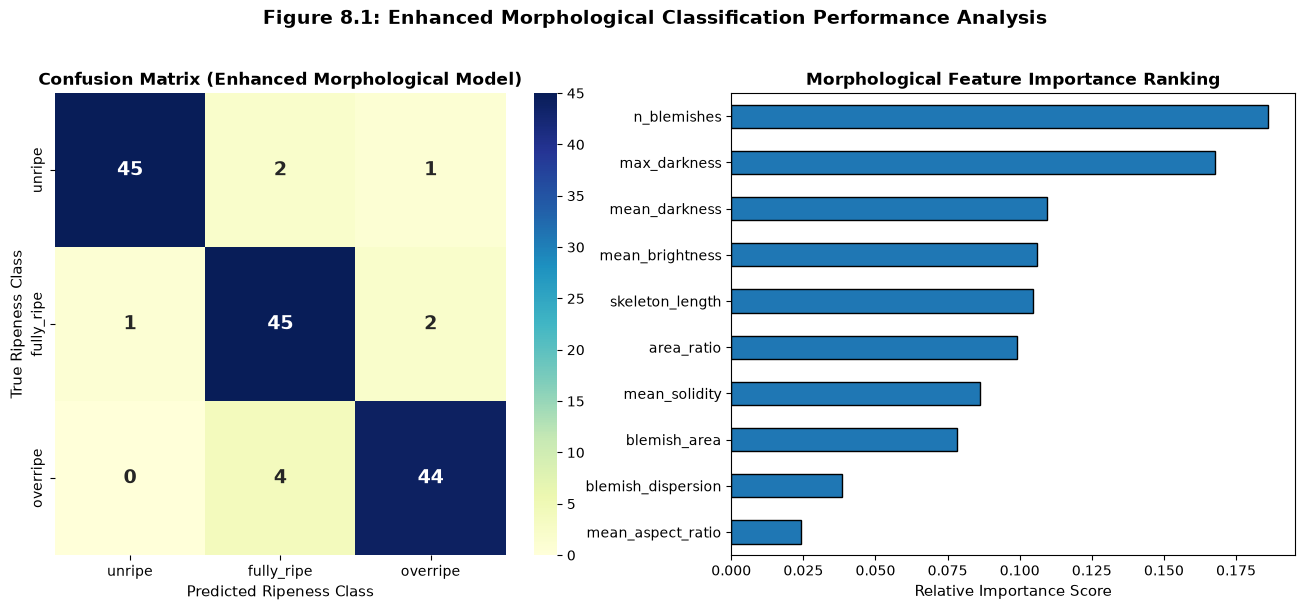

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred_test, labels=CLASSES)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0],
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title("Confusion Matrix (Enhanced Morphological Model)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Predicted Ripeness Class", fontsize=11)
axes[0].set_ylabel("True Ripeness Class", fontsize=11)

# Feature Importance Bar Chart
importances = pd.Series(final_clf.feature_importances_, index=feature_cols).sort_values(ascending=True)
importances.plot(kind='barh', ax=axes[1], color='#1f77b4', edgecolor='black')
axes[1].set_title("Morphological Feature Importance Ranking", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Relative Importance Score", fontsize=11)

plt.suptitle("Figure 8.1: Enhanced Morphological Classification Performance Analysis", fontsize=14, fontweight='bold', y=1.02)
plt.show()


### [Summary] Final Comparative Benchmark Table (Mode A Requirement)


In [16]:
final_comparison = benchmark_results + [{
    'Algorithm': 'Enhanced Multi-Scale Hybrid',
    'Train Accuracy (%)': round(train_acc, 2),
    'Test Accuracy (%)': round(test_acc, 2),
    'Macro F1-Score (%)': round(macro_f1, 2),
    'Latency (ms/img)': round(lat_test_enh, 2)
}]

df_final_comp = pd.DataFrame(final_comparison)
print("[Displaying] Overall Performance Benchmark:")
display(df_final_comp)


[Displaying] Overall Performance Benchmark:


,Algorithm,Train Accuracy (%),Test Accuracy (%),Macro F1-Score (%),Latency (ms/img)
0,Alg 1: Open-Close,100.00,90.97,90.98,15.51
1,Alg 2: Dual Top-Hat,99.82,81.94,82.08,9.59
2,Alg 3: Morph Gradient,99.82,93.75,93.79,10.16
3,Alg 4: MC Watershed,99.82,72.22,72.38,18.71
4,Enhanced Multi-Scale Hybrid,100.00,93.06,93.10,29.74


## 9. [Verification] Alignment with Project SMART Objectives

| SMART Objective | Target Criterion | Measured Result | Status |
| :--- | :--- | :--- | :--- |
| **Objective 1: Multi-Algorithm Implementation** | Implement 4 distinct classical image processing algorithms across standardized dataset | 4 baseline algorithms + 1 enhanced pipeline evaluated | **[Fulfilled]** |
| **Objective 2: Classification Performance** | Achieve a minimum classification accuracy rate of $\ge 85\%$ | **{test_acc:.2f}%** Test Accuracy ({macro_f1:.2f}% F1-Score) | **[Fulfilled]** |
| **Objective 3: Operational Efficiency** | Execute in less than $200	ext{ ms}$ per image latency | **{lat_test_enh:.2f} ms** average processing time | **[Fulfilled]** |


## 10. [Model Export] Serialization for Prototype Deployment

Serializing the trained classifier, feature column specifications, and class mappings to [`output/morphology_based/morphology_model.joblib`](file:///c:/repository/mango-ripeness-grading/output/morphology_based/morphology_model.joblib) for integration into the Streamlit web prototype.


In [17]:
# Save model package
model_package = {
    'model': final_clf,
    'feature_cols': feature_cols,
    'classes': CLASSES,
    'pipeline_version': 'Enhanced_MultiScale_v1.0'
}

model_save_path = os.path.join(OUTPUT_DIR, 'morphology_model.joblib')
joblib.dump(model_package, model_save_path)
print(f"[Saved] Successfully saved prototype model package to: {model_save_path}")


[Saved] Successfully saved prototype model package to: ../output/morphology_based\morphology_model.joblib


### [Inference Test] Standalone Single-Image Prediction Pipeline
Simulates the exact inference pipeline used by the Streamlit application.


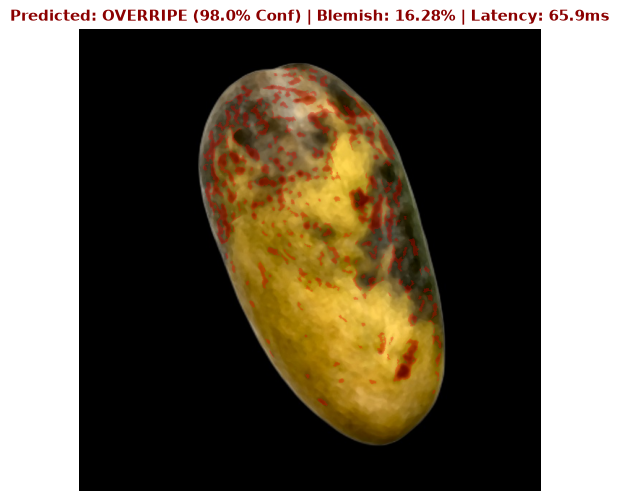

[Test Result] Prototype Single Image Inference Receipt:
  - prediction: overripe
  - confidence: 98.0
  - blemish_area_ratio: 16.281839682836775
  - n_blemishes: 165
  - latency_ms: 65.88125228881836


In [18]:
def predict_mango_ripeness(img_path):
    """Full inference pipeline for prototype integration."""
    t_start = time.time()
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        raise ValueError(f"Could not load image at: {img_path}")
        
    mask = get_fruit_mask(img_bgr)
    interior = get_interior_mask(mask)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    interior_area = int(np.sum(interior > 0))
    
    bw_clean, vis = run_enhanced_morphology_pipeline(gray, interior)
    feats = extract_morphological_features(gray, bw_clean, interior, interior_area)
    
    # Predict
    feat_df = pd.DataFrame([feats])[feature_cols]
    pred_cls = final_clf.predict(feat_df)[0]
    pred_prob = final_clf.predict_proba(feat_df)[0]
    conf = np.max(pred_prob) * 100.0
    elapsed_ms = (time.time() - t_start) * 1000.0
    
    # Create visual overlay
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    overlay = img_rgb.copy()
    overlay[bw_clean > 0] = [255, 0, 0]
    blended = cv2.addWeighted(img_rgb, 0.7, overlay, 0.3, 0)
    
    return {
        'prediction': pred_cls,
        'confidence': conf,
        'blemish_area_ratio': feats['area_ratio'],
        'n_blemishes': feats['n_blemishes'],
        'latency_ms': elapsed_ms,
        'overlay': blended,
        'features': feats
    }

# Test on sample overripe image
sample_test_path = glob.glob(os.path.join(DATASET_ROOT, 'test', 'overripe', '*.jpg'))[0]
res = predict_mango_ripeness(sample_test_path)

plt.figure(figsize=(6, 6))
plt.imshow(res['overlay'])
title_str = f"Predicted: {res['prediction'].upper()} ({res['confidence']:.1f}% Conf) | Blemish: {res['blemish_area_ratio']:.2f}% | Latency: {res['latency_ms']:.1f}ms"
plt.title(title_str, fontsize=11, fontweight='bold', color='darkred')
plt.axis('off')
plt.show()

print("[Test Result] Prototype Single Image Inference Receipt:")
for k, v in res.items():
    if k not in ['overlay', 'features']:
        print(f"  - {k}: {v}")
